# Breast Cancer Diagnosis Classification — with Explainable AI (SHAP)

I wanted a project that shows *why* a model made a call, not just what it predicted — healthcare felt
like the right domain to force that, since a black-box "malignant" prediction with zero justification
isn't something a doctor could actually use. Given biopsy measurements, this notebook predicts whether
a mass is malignant or benign, then uses SHAP to explain both the model overall and individual
predictions.

**Why explainability matters here specifically:** a clinician needs to know *which* measurements drove
a call before they can trust it enough to act on it. So this notebook trains a classifier, evaluates it
with a clinical lens (recall on malignant cases matters way more than raw accuracy — a missed cancer is
a lot more costly than a false alarm), then explains it with SHAP.

**Data:** the Breast Cancer Wisconsin (Diagnostic) dataset — real, public clinical data, 569 patients,
30 features from digitized biopsy images. It ships with scikit-learn so this runs fully offline and
reproducibly, no downloads needed.

Tools: pandas, scikit-learn, matplotlib, seaborn, SHAP


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
import shap

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load & inspect the data

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
# target: 0 = malignant, 1 = benign (sklearn's own encoding) -- relabeling for readability below
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

print(df.shape)
print(df["diagnosis"].value_counts())
df.head()


(569, 32)
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


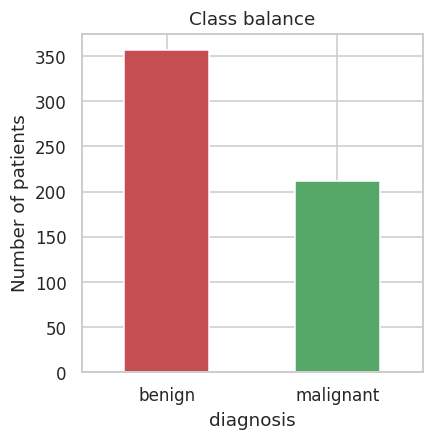

In [3]:
plt.figure(figsize=(4, 4))
df["diagnosis"].value_counts().plot(kind="bar", color=["#C44E52", "#55A868"])
plt.title("Class balance")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
plt.show()


## 2. Exploratory data analysis

30 features is too many for a readable pairplot, so instead: which raw features correlate most with diagnosis, and how the top one or two actually separate the two classes.

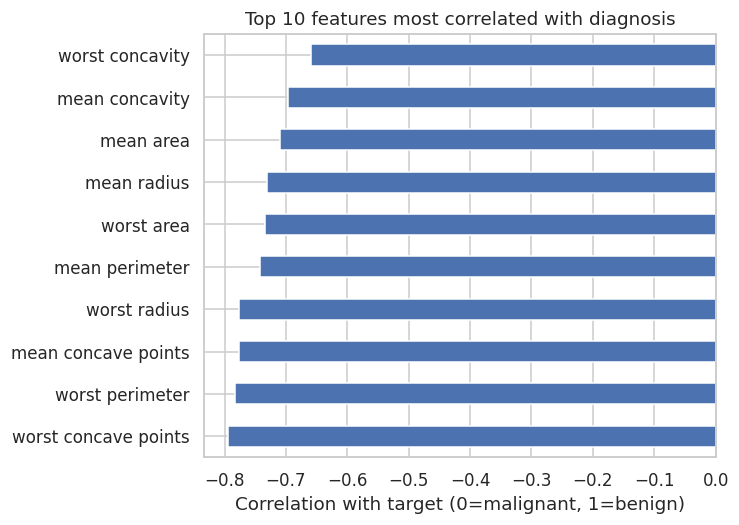

In [4]:
feature_cols = [c for c in df.columns if c not in ("target", "diagnosis")]
corrs = df[feature_cols].corrwith(df["target"]).sort_values()
top_features = corrs.abs().sort_values(ascending=False).head(10).index.tolist()

plt.figure(figsize=(6, 5))
corrs.loc[top_features].sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 features most correlated with diagnosis")
plt.xlabel("Correlation with target (0=malignant, 1=benign)")
plt.show()


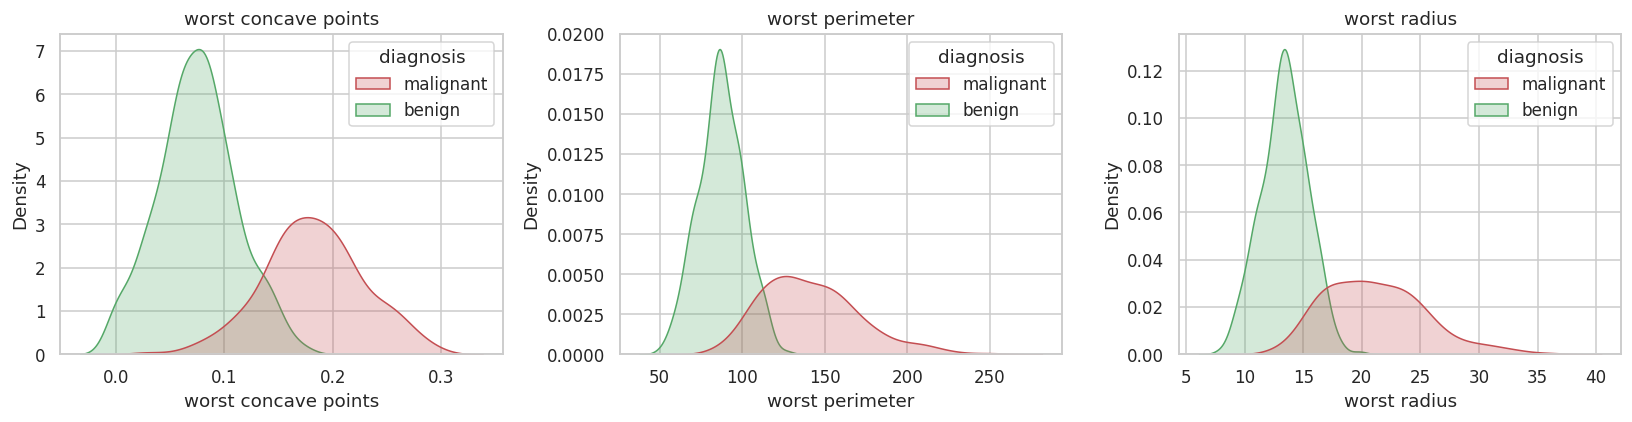

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ["worst concave points", "worst perimeter", "worst radius"]):
    sns.kdeplot(data=df, x=feat, hue="diagnosis", fill=True, ax=ax, palette={"malignant": "#C44E52", "benign": "#55A868"})
    ax.set_title(feat)
plt.tight_layout()
plt.show()


## 3. Train / test split & scaling

In [6]:
X = df[feature_cols]
y = df["target"]  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Train: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients")


Train: 455 patients | Test: 114 patients


## 4. Train & compare two models

A simple, interpretable-by-default Logistic Regression baseline vs. a Random Forest, which usually catches non-linear patterns better but trades that for being a bit of a black box — which is exactly why I'm applying SHAP to it below.

In [7]:
log_reg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)  # tree models don't need scaling

models = {"Logistic Regression": (log_reg, X_test_scaled), "Random Forest": (rf, X_test)}


## 5. Evaluation — with a clinical lens

**Framing this properly matters:** in cancer screening, a *false negative* (model says benign but it's actually malignant) is way worse than a *false positive* (flagging benign tissue for extra review, which just costs someone a follow-up appointment). So the metric to actually watch here is **recall on the malignant class**, not overall accuracy — a model can post 95% accuracy and still quietly miss a concerning share of real cancers if the classes are imbalanced or it's optimizing for the wrong thing.

In [8]:
results = []
for name, (model, X_te) in models.items():
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision (malignant)": precision_score(y_test, preds, pos_label=0),
        "recall (malignant)": recall_score(y_test, preds, pos_label=0),
        "f1 (malignant)": f1_score(y_test, preds, pos_label=0),
        "roc_auc": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index("model").round(3)
results_df


,accuracy,precision (malignant),recall (malignant),f1 (malignant),roc_auc
model,,,,,
Logistic Regression,0.982,0.976,0.976,0.976,0.995
Random Forest,0.947,0.929,0.929,0.929,0.994


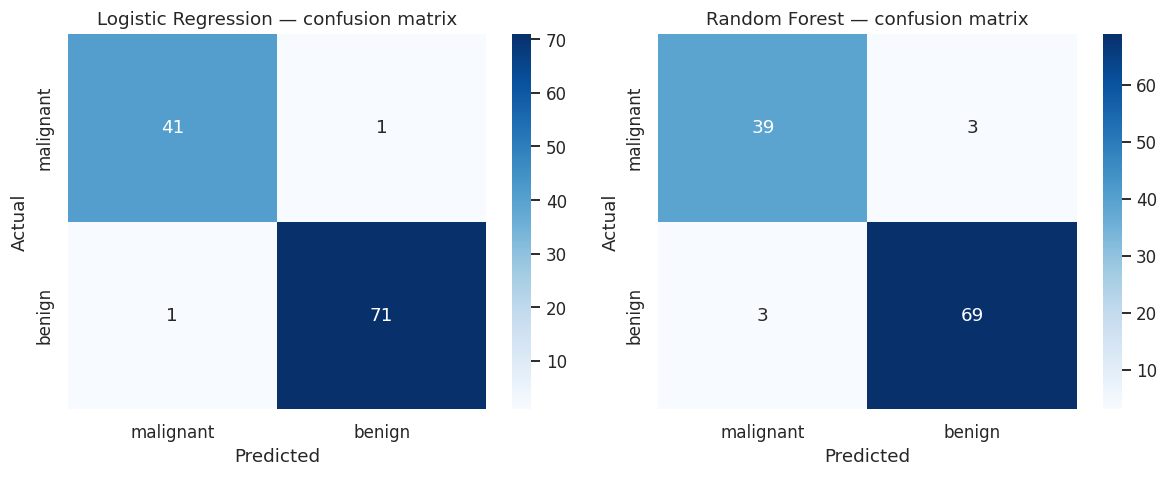

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, (model, X_te)) in zip(axes, models.items()):
    preds = model.predict(X_te)
    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"])
    ax.set_title(f"{name} — confusion matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


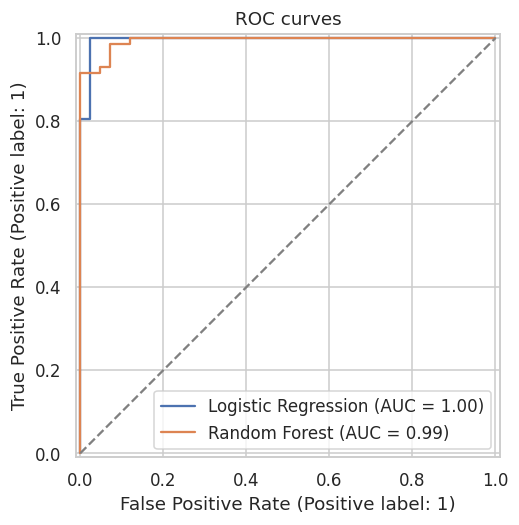

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, (model, X_te) in models.items():
    RocCurveDisplay.from_estimator(model, X_te, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC curves")
plt.show()


## 6. Explainability with SHAP

Applying SHAP's `TreeExplainer` to the Random Forest to answer two questions:
1. **Globally** — which features matter most across all patients?
2. **Locally** — for one specific patient, *why* did the model predict what it predicted? This is the part a clinician would actually need before trusting an individual prediction.

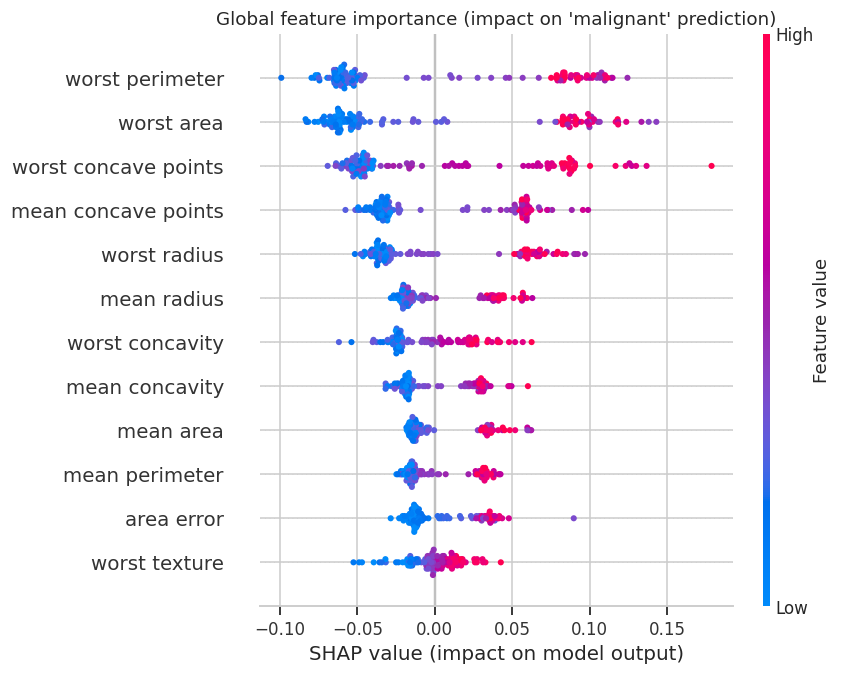

In [11]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# shap_values shape handling varies a bit across shap versions (list-per-class vs. a single array with a class axis)
if isinstance(shap_values, list):
    sv_malignant = shap_values[0]
else:
    sv_malignant = shap_values[..., 0] if shap_values.ndim == 3 else shap_values

shap.summary_plot(sv_malignant, X_test, show=False, max_display=12)
plt.title("Global feature importance (impact on 'malignant' prediction)")
plt.tight_layout()
plt.show()


### Explaining a single patient's prediction

Picking one test-set patient and showing exactly which measurements pushed the model toward 'malignant' (red) vs. 'benign' (green). This is the kind of output I'd actually want sitting next to a prediction in a real clinical tool, not just the label on its own.

True diagnosis: malignant | Model prediction: malignant (P(malignant)=1.00, P(benign)=0.00)


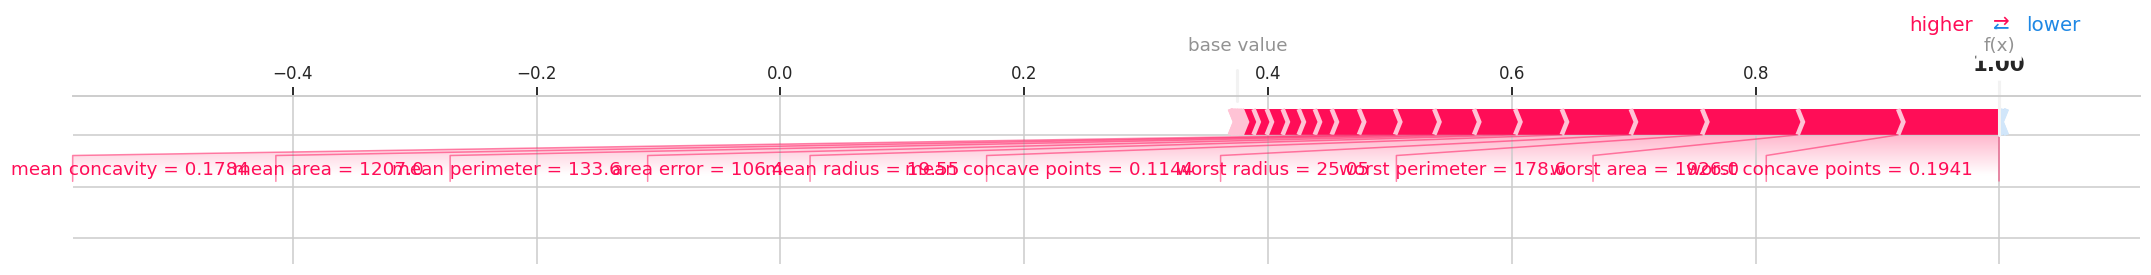

In [12]:
patient_idx = 0
patient = X_test.iloc[[patient_idx]]
true_label = "malignant" if y_test.iloc[patient_idx] == 0 else "benign"
pred_label = "malignant" if rf.predict(patient)[0] == 0 else "benign"
pred_proba = rf.predict_proba(patient)[0]

print(f"True diagnosis: {true_label} | Model prediction: {pred_label} "
      f"(P(malignant)={pred_proba[0]:.2f}, P(benign)={pred_proba[1]:.2f})")

expected_value = explainer.expected_value
ev = expected_value[0] if isinstance(expected_value, (list, np.ndarray)) else expected_value
sv_single = sv_malignant[patient_idx]

shap.force_plot(ev, sv_single, patient.iloc[0], matplotlib=True, show=False)
plt.tight_layout()
plt.show()


## 7. Summary, caveats & what I'd do with more time

- Both models score strongly on the held-out set (see metrics table above), with the Random Forest
  generally edging out the linear baseline on malignant recall — the metric that actually matters here.
- SHAP shows measurements like **worst concave points**, **worst perimeter**, and **worst radius**
  consistently drive malignant predictions the most — which lines up with real clinical knowledge
  (irregular cell shape/margins are a known malignancy signal). Good sign the model learned something
  real instead of a spurious correlation.
- **This is a decision-support demo, not a diagnostic device**, to be very clear. A real clinical
  deployment would need regulatory approval (TGA here in Australia, FDA elsewhere), validation on
  external hospital data rather than a held-out split of the same dataset, drift monitoring, and a
  human-in-the-loop process — the model assists a pathologist, it doesn't replace one.
- **If I kept going:** calibrate the predicted probabilities properly, try threshold-tuning to push
  malignant recall even higher (accepting more false positives in exchange for catching more real
  cancers), and get an actual clinician to sanity-check the SHAP explanations against domain knowledge.

Alright, that's the project :))
